# Predição de Desempenho de GPU (SGEMM) com Regressão Linear
- https://archive.ics.uci.edu/dataset/440/sgemm+gpu+kernel+performance
  
Este conjunto de dados registra o tempo que uma placa de vídeo leva para calcular multiplicações de matrizes de tamanho 2048x2048. O desempenho de uma GPU varia drasticamente dependendo de como configuramos a divisão do trabalho, o uso da memória interna e a organização das tarefas.

Em vez de focar na matemática exata da operação, o objetivo do dataset é puramente prático. O dataset contém centenas de milhares de combinações de otimização de hardware testadas, com os tempos de execução medidos em milissegundos.


In [1]:
import os
import requests
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import RidgeCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

## 1. Download: Baixa e extrai o CSV diretamente do repositório da UCI

In [3]:
def download_and_extract_dataset():
    url = "https://archive.ics.uci.edu/static/public/440/sgemm+gpu+kernel+performance.zip"
    zip_path = "dataset.zip"
    csv_filename = "sgemm_product.csv"

    try:
        if os.path.exists(csv_filename):
            return csv_filename

        print("Baixando o dataset")
        response = requests.get(url, stream=True)
        response.raise_for_status()

        with open(zip_path, 'wb') as f:
            for chunk in response.iter_content(chunk_size=8192):
                f.write(chunk)

        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            # Extrai apenas o CSV, ignorando a pasta _MACOSX e o Readme
            zip_ref.extract(csv_filename, path=".")

        # Limpa o arquivo zip baixado
        os.remove(zip_path)
        return csv_filename

    except Exception as e:
        print(e)
        return None

csv_file = download_and_extract_dataset()

## 2. Pré-processamento e EDA: Calcula a média do tempo das 4 execuções e aplica o logaritmo natural. Gera gráficos para entender a distribuição e correlações.

In [5]:
def load_and_prepare_data(filepath):
    try:
        df = pd.read_csv(filepath)
        X = df.iloc[:, :14]
        y_raw = df.iloc[:, 14:18].mean(axis=1)
        y = np.log(y_raw).rename("Log_Tempo_Execucao")
        return X, y

    except Exception as e:
        print(e)
        return None, None

In [6]:
def plot_exploratory_data(X, y):
    try:
        sns.set_theme(style="whitegrid")

        # Histograma
        plt.figure(figsize=(10, 5))
        sns.histplot(y, bins=50, kde=True, color='blue')
        plt.title('Distribuição do Logaritmo do Tempo de Execução')
        plt.xlabel('Log(Milissegundos)')
        plt.ylabel('Frequência')
        plt.show()

        # Matriz de Correlação
        df_exploratory = pd.concat([X, y], axis=1)
        corr_matrix = df_exploratory.corr()

        plt.figure(figsize=(12, 10))
        sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True, square=True)
        plt.title('Matriz de Correlação')
        plt.show()

    except Exception as e:
        print(e)


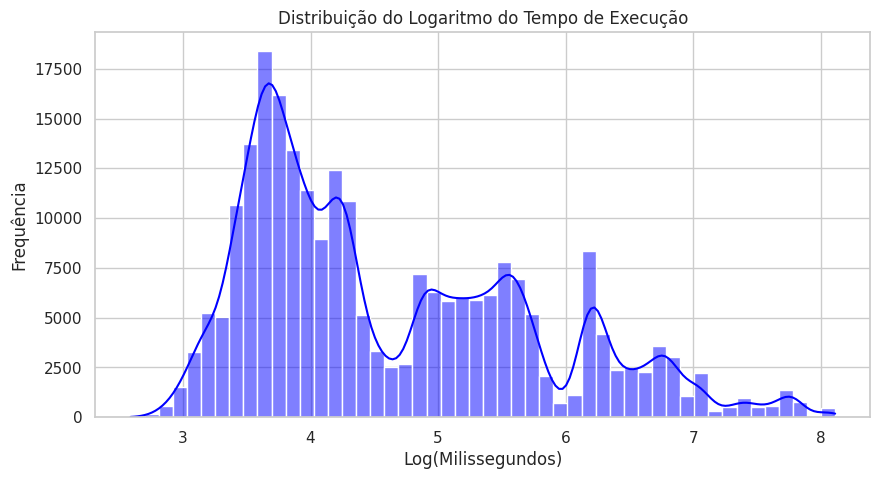

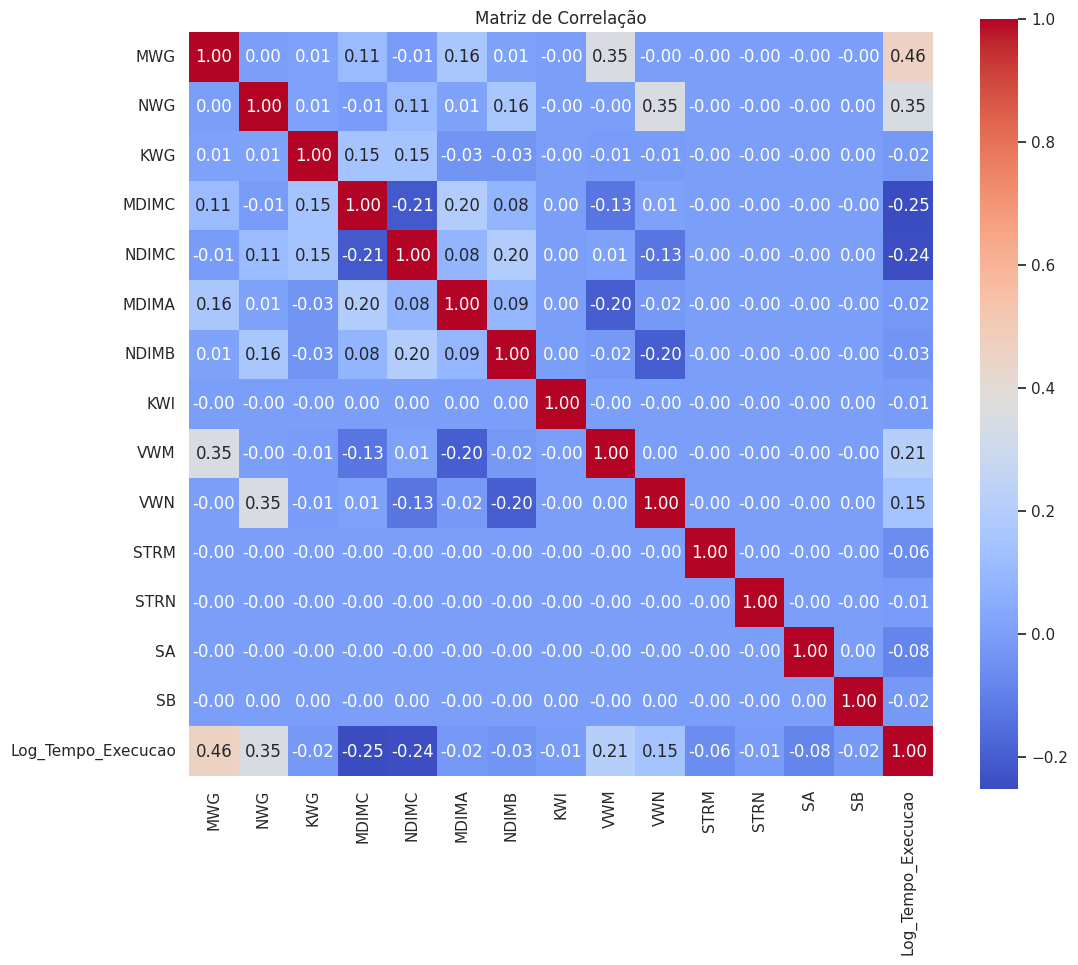

In [7]:
if csv_file:
    X, y = load_and_prepare_data(csv_file)
    if X is not None:
        plot_exploratory_data(X, y)

## 3. Treinamento e Avaliação: Utiliza Regressão Linear Regularizada (RidgeCV) e gera gráficos e métricas para avaliação

In [10]:
def train_and_evaluate_model(X, y):

    try:
        X_train, X_test, y_train, y_test = train_test_split(
            X.values, y.values, test_size=0.2, random_state=42
        )

        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            # Cria features polinomiais pra regressão capturar elhor as interações entre os parâmetros.
            ('poly', PolynomialFeatures(degree=2, include_bias=False)),
            ('ridge', RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0]))
        ])

        print("\nTreinando o modelo")
        pipeline.fit(X_train, y_train)

        # Previsão e Métricas
        y_pred = pipeline.predict(X_test)

        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        best_alpha = pipeline.named_steps['ridge'].alpha_

        print("\nResultados:")
        print(f"R2: {r2:.4f}")
        print(f"RMSE: {rmse:.4f}")
        print(f"MAE: {mae:.4f}")
        print(f"Alpha selecionado: {best_alpha}")

        return y_test, y_pred

    except Exception as e:
        print(e)
        return None, None

y_test_final, y_pred_final = None, None



In [14]:
def plot_model_results(y_test, y_pred):

    try:
        print("Gerando gráficos de avaliação")
        sns.set_theme(style="whitegrid")
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))

        # Valores Reais x Previsões
        # A linha vermelha representa a previsão perfeita
        axes[0].scatter(y_test, y_pred, alpha=0.1, color='blue', s=10)

        min_val = min(y_test.min(), y_pred.min())
        max_val = max(y_test.max(), y_pred.max())
        axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)

        axes[0].set_title('Valores Reais x Previsões')
        axes[0].set_xlabel('Tempo Real (Log)')
        axes[0].set_ylabel('Tempo Previsto (Log)')

        # Distribuição dos Resíduos
        # Verifica se os erros seguem uma distribuição normal em torno de zero
        residuos = y_test - y_pred
        sns.histplot(residuos, bins=50, kde=True, ax=axes[1], color='red')
        axes[1].axvline(0, color='black', linestyle='--', lw=2)

        axes[1].set_title('Distribuição dos Resíduos')
        axes[1].set_xlabel('Erro (Real - Previsto)')
        axes[1].set_ylabel('Frequência')

        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(e)



Treinando o modelo

Resultados:
R2: 0.8135
RMSE: 0.4850
MAE: 0.3901
Alpha selecionado: 10.0
Gerando gráficos de avaliação


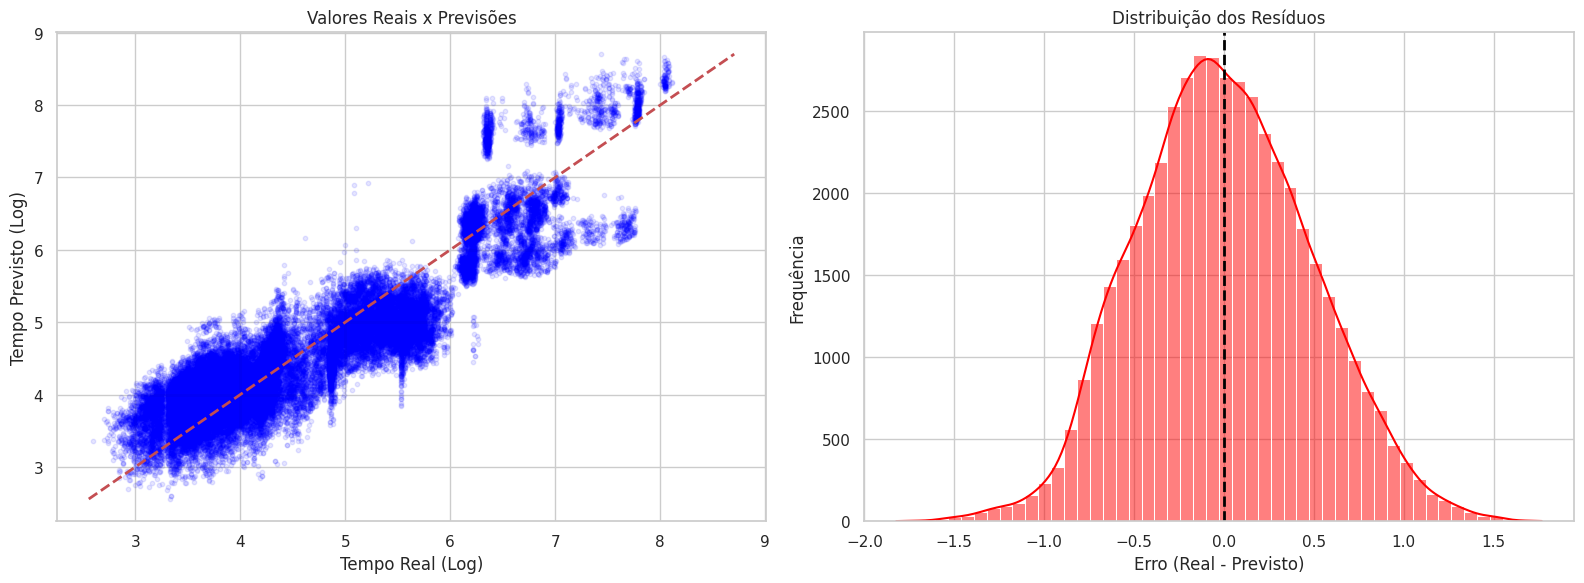

In [15]:
if 'csv_file' in locals() and csv_file and X is not None:
    y_test_final, y_pred_final = train_and_evaluate_model(X, y)

if y_test_final is not None and y_pred_final is not None:
    plot_model_results(y_test_final, y_pred_final)
